In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Membaca Dataset Mentah CO (365 Hari)
raw_path = '../data/csv/CO_gresik_timeseries.csv'
df_raw = pd.read_csv(raw_path)
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw = df_raw.sort_values('date').reset_index(drop=True)

# Hitung statistik celah data awal
total_rows = len(df_raw)
nan_awal = df_raw['CO'].isna().sum()
valid_awal = df_raw['CO'].notna().sum()

print(f"Total Baris Observasi   : {total_rows} hari")
print(f"Jumlah Data Valid Awal  : {valid_awal} hari ({valid_awal/total_rows*100:.2f}%)")
print(f"Jumlah Missing (NaN)    : {nan_awal} hari ({nan_awal/total_rows*100:.2f}%)")

Total Baris Observasi   : 365 hari
Jumlah Data Valid Awal  : 192 hari (52.60%)
Jumlah Missing (NaN)    : 173 hari (47.40%)


In [2]:
# 2. Deteksi Outlier dengan Metode IQR pada Data Valid
q1 = df_raw['CO'].quantile(0.25)
q3 = df_raw['CO'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Masking Outlier
is_outlier = (df_raw['CO'] < lower_bound) | (df_raw['CO'] > upper_bound)
jumlah_outlier = is_outlier.sum()

print(f"Kuartil 1 (Q1)           : {q1:.6f} mol/m²")
print(f"Kuartil 3 (Q3)           : {q3:.6f} mol/m²")
print(f"IQR (Q3 - Q1)            : {iqr:.6f} mol/m²")
print(f"Batas Bawah (Lower Bound): {lower_bound:.6f} mol/m²")
print(f"Batas Atas (Upper Bound) : {upper_bound:.6f} mol/m²")
print(f"Jumlah Outlier Terdeteksi: {jumlah_outlier} hari")

# Tabel Detail Tanggal & Nilai Outlier Terdeteksi
df_outliers = df_raw[is_outlier][['date', 'CO']].copy()
df_outliers['date'] = df_outliers['date'].dt.strftime('%Y-%m-%d')
print("\nDaftar Tanggal & Nilai Outlier Terdeteksi secara Akurat:")
print(df_outliers.to_string(index=False))

Kuartil 1 (Q1)           : 0.026530 mol/m²
Kuartil 3 (Q3)           : 0.030774 mol/m²
IQR (Q3 - Q1)            : 0.004244 mol/m²
Batas Bawah (Lower Bound): 0.020164 mol/m²
Batas Atas (Upper Bound) : 0.037140 mol/m²
Jumlah Outlier Terdeteksi: 11 hari

Daftar Tanggal & Nilai Outlier Terdeteksi secara Akurat:
      date       CO
2025-09-14 0.017361
2025-09-24 0.041642
2025-10-08 0.039112
2025-10-09 0.045237
2026-04-05 0.017621
2026-05-05 0.017592
2026-05-12 0.016968
2026-06-13 0.018679
2026-07-15 0.019071
2026-08-10 0.038350
2026-08-14 0.039100


In [3]:
# 3. Pengosongan Nilai Outlier menjadi NaN
df_prep = df_raw.copy()
df_prep.loc[is_outlier, 'CO'] = np.nan
nan_setelah_outlier = df_prep['CO'].isna().sum()

# 4. Imputasi Linear Time Interpolation Sekaligus
df_clean = df_prep.copy()
df_clean['CO_clean'] = df_clean['CO'].interpolate(method='linear', limit_direction='both')
nan_akhir = df_clean['CO_clean'].isna().sum()

print(f"Jumlah NaN Setelah Outlier Dikosongkan : {nan_setelah_outlier} hari ({nan_setelah_outlier/total_rows*100:.2f}%)")
print(f"Jumlah NaN Setelah Imputasi Akhir      : {nan_akhir} hari (100% Terisi & Clean)")

# Simpan dataset bersih ke file CSV
df_save = df_clean[['date', 'CO_clean']].rename(columns={'CO_clean': 'CO'})
df_save.to_csv('../data/csv/CO_clean.csv', index=False)
print("Dataset bersih disimpan ke '../data/csv/CO_clean.csv'")

Jumlah NaN Setelah Outlier Dikosongkan : 184 hari (50.41%)
Jumlah NaN Setelah Imputasi Akhir      : 0 hari (100% Terisi & Clean)
Dataset bersih disimpan ke '../data/csv/CO_clean.csv'


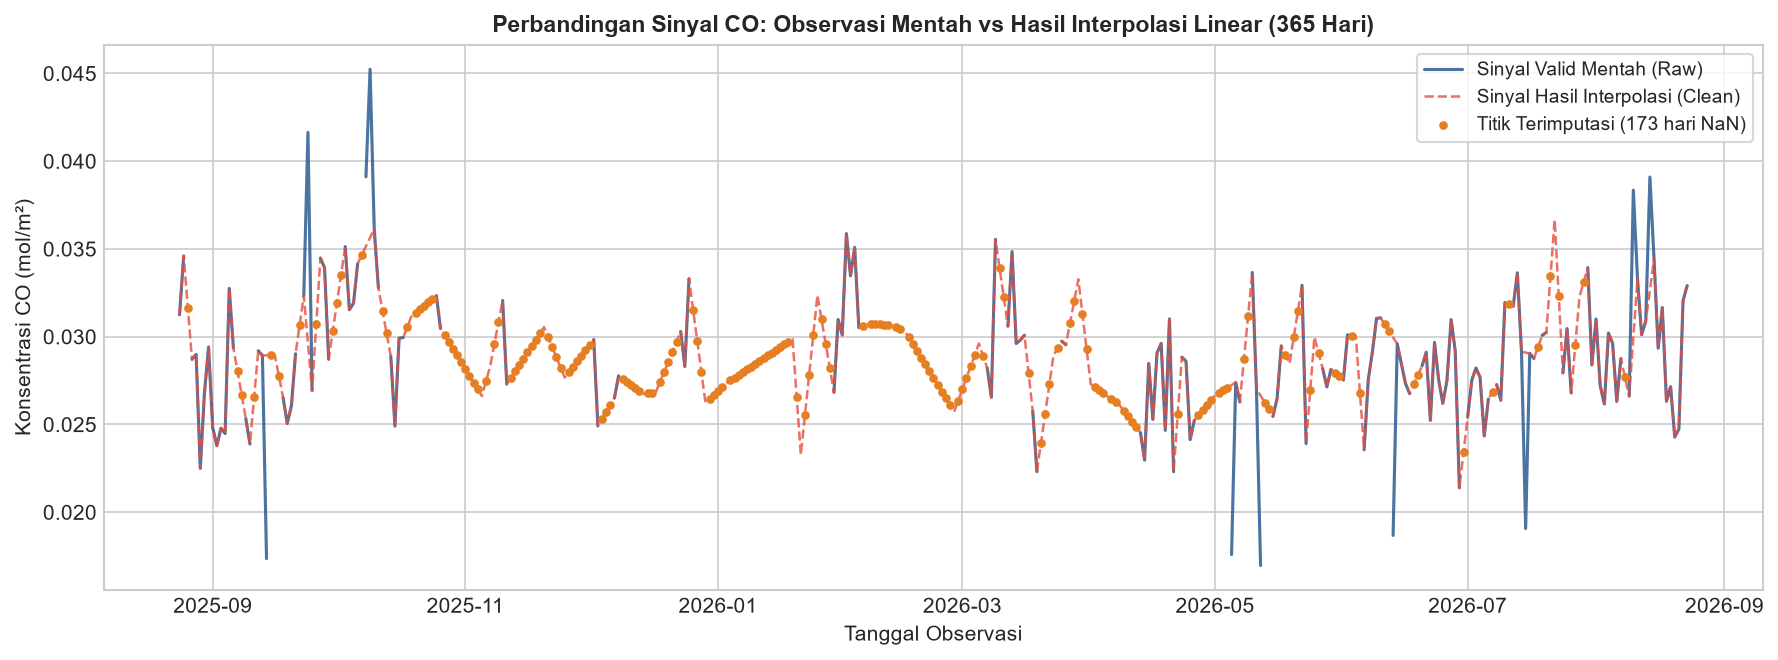

In [4]:
# Set Visual Style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Visualisasi 1: Missing Imputation Comparison Plot
fig, ax = plt.subplots(figsize=(12, 4.5), dpi=150)
ax.plot(df_raw['date'], df_raw['CO'], label='Sinyal Valid Mentah (Raw)', color='#2b5c8f', linewidth=1.5, alpha=0.85)
ax.plot(df_clean['date'], df_clean['CO_clean'], label='Sinyal Hasil Interpolasi (Clean)', color='#e74c3c', linestyle='--', linewidth=1.2, alpha=0.8)

missing_mask = df_raw['CO'].isna()
ax.scatter(df_raw.loc[missing_mask, 'date'], df_clean.loc[missing_mask, 'CO_clean'], 
           color='#e67e22', s=10, label=f'Titik Terimputasi ({nan_awal} hari NaN)', zorder=4)

ax.set_title('Perbandingan Sinyal CO: Observasi Mentah vs Hasil Interpolasi Linear (365 Hari)', fontsize=11, fontweight='bold')
ax.set_xlabel('Tanggal Observasi', fontsize=10)
ax.set_ylabel('Konsentrasi CO (mol/m²)', fontsize=10)
ax.legend(loc='upper right', frameon=True, facecolor='white', fontsize=9)
plt.tight_layout()
plt.show()

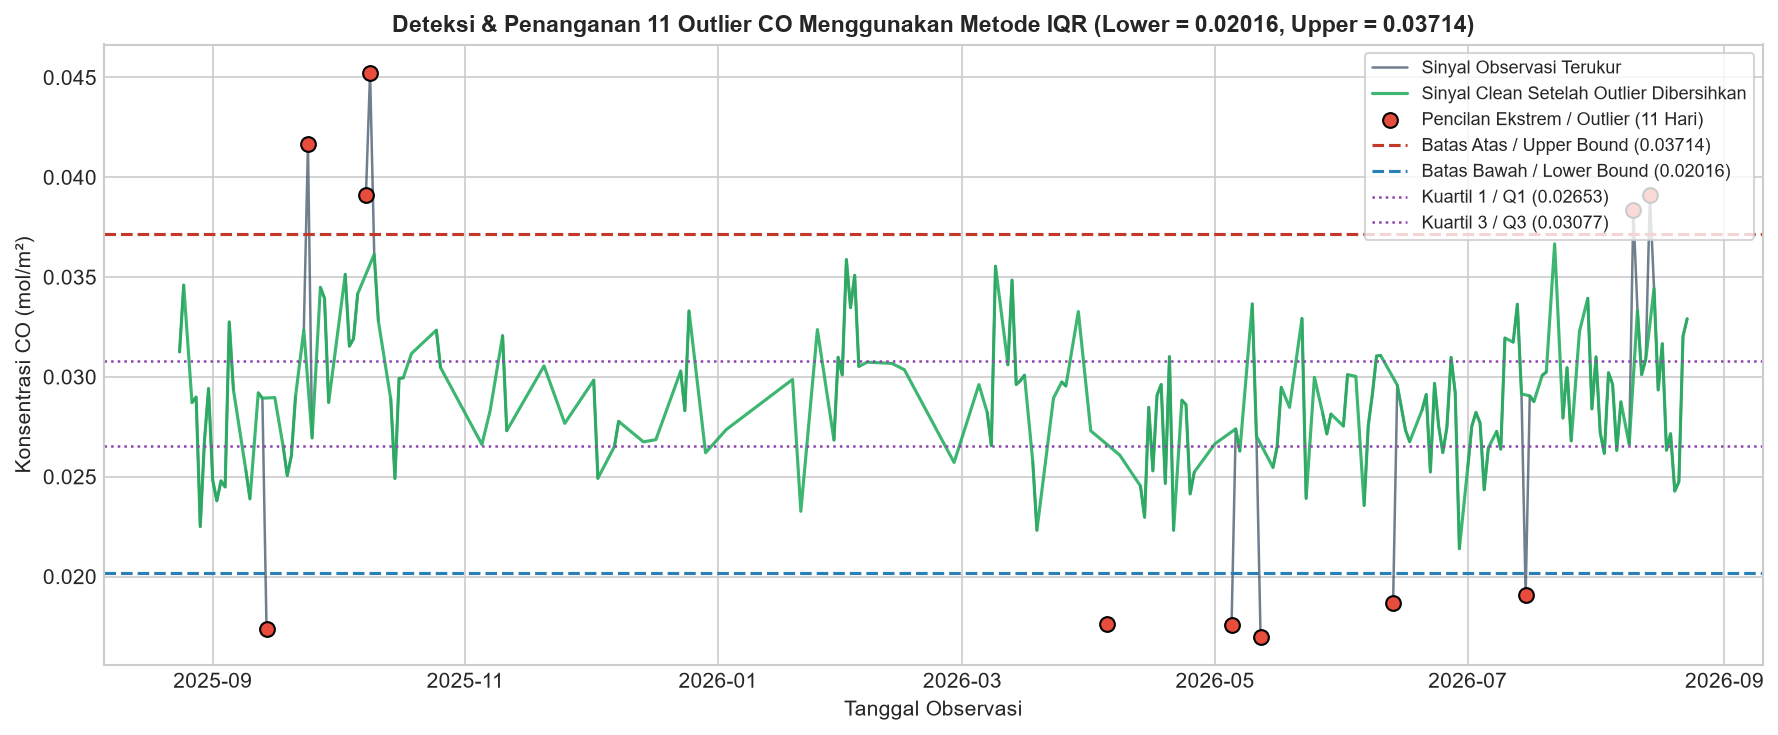

In [5]:
# Visualisasi 2: Outlier Detection & IQR Bounds Plot
fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

# Plot sinyal mentah & sinyal clean
ax.plot(df_raw['date'], df_raw['CO'], label='Sinyal Observasi Terukur', color='#34495e', linewidth=1.2, alpha=0.7)
ax.plot(df_clean['date'], df_clean['CO_clean'], label='Sinyal Clean Setelah Outlier Dibersihkan', color='#27ae60', linewidth=1.5, alpha=0.9)

# Scatter Outlier Points
outliers_plot = df_raw[is_outlier]
ax.scatter(outliers_plot['date'], outliers_plot['CO'], color='#e74c3c', s=50, zorder=5, marker='o', edgecolor='black', linewidth=1, label=f'Pencilan Ekstrem / Outlier ({jumlah_outlier} Hari)')

# Garis Batas IQR
ax.axhline(upper_bound, color='#c0392b', linestyle='--', linewidth=1.5, label=f'Batas Atas / Upper Bound ({upper_bound:.5f})')
ax.axhline(lower_bound, color='#2980b9', linestyle='--', linewidth=1.5, label=f'Batas Bawah / Lower Bound ({lower_bound:.5f})')
ax.axhline(q1, color='#8e44ad', linestyle=':', linewidth=1.2, label=f'Kuartil 1 / Q1 ({q1:.5f})')
ax.axhline(q3, color='#8e44ad', linestyle=':', linewidth=1.2, label=f'Kuartil 3 / Q3 ({q3:.5f})')

ax.set_title(f'Deteksi & Penanganan {jumlah_outlier} Outlier CO Menggunakan Metode IQR (Lower = {lower_bound:.5f}, Upper = {upper_bound:.5f})', fontsize=11, fontweight='bold')
ax.set_xlabel('Tanggal Observasi', fontsize=10)
ax.set_ylabel('Konsentrasi CO (mol/m²)', fontsize=10)
ax.legend(loc='upper right', frameon=True, facecolor='white', fontsize=8.5)
plt.tight_layout()
plt.show()